Problem Question: identify fraudulent or high-risk bank transactions

Working as a System Administrator in the banking sector, I operate at the heart of where money meets technology. Banks are built on trust and transactions, but every day, that trust is tested by fraud attempts—some thwarted, others successful. While we have dedicated security teams, I realized that as a Middleware professional handling complex integrationsand have understanding how data flows between systems, i want to understand what type of transactions are most prone to fraud.

So using the data analysis understanding i have i want to look deeper into the data to identify which transactions are most prone to fraud.  Additionally, such kind of datasets can also be used to other purposes like: Which age groups are our most active users, and which channels (Mobile, Web, ATM) do they prefer? This information can help a company anticipate customer needs rather than just reacting to them?

challenges faced: 

 Due to strict data privacy and banking regulations, I could not use our institution’s live production data for my access to use the banks transaction data. However, to prove the value of data-driven recommendations, I turned to a high-fidelity dataset from Kaggle that mirrors real-world banking behaviors. This allowed me to build a proof-of-concept without compromising any real-world security or privacy.

The Insight: Data as a Shield and a Compass
By applying Anomaly Detection (Isolation Forest) to this data, I moved from a reactive "Middleware" mindset to a proactive "Data Intelligence" mindset. I discovered that simple variables—like a sudden spike in login attempts—are often more telling than the transaction amount itself. This journey proves that data isn't just a byproduct of banking; it is the most useful tool we have for operational performance, security, and understanding our customer base.

In [164]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

<b>Step1: Data Cleaning</b>

In [166]:
#Bank Transactions Dataset
# The dataset used is sourced from kaggle "Bank Transactions Dataset for Fraud Detection"

url = 'https://raw.githubusercontent.com/hiwotamare123/fraud-detection/main/bank_transactions_data_2_augmented_clean_2.csv'
df = pd.read_csv(url)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [167]:
#summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [168]:
# descriptive statistics for numerical columns, the data distribution.
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [169]:
#look in to the dataset if there are any missing value to handle them
print(df.isnull().sum())

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64


In [170]:
# Check for duplicates
print(df.duplicated().sum())

0


now that we have clear vision of the dataset and there are no null and duplicated vales we will be handling data types in the next step

In [172]:
#handle data types
# Convert 'TransactionDate' to datetime objects to allow for time-based analysis
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
# Feature Extraction: Extract the hour of the day
# This helps the model identify if transactions occurring at 3 AM are riskier than those at 3 PM.
df['Hour'] = df['TransactionDate'].dt.hour

In [173]:
print(f"Analysing Transaction data from {df['TransactionDate'].min()} to {df['TransactionDate'].max()}")

Analysing Transaction data from 2020-01-01 00:00:00 to 2025-12-31 00:00:00


<b> Step2: Feature Extraction</b>

While working on this project i have few discussion with soc analysts who works on netgurdians and many analysis tools and the pointed out that Athought, there are different threats in the attempts of fraud, the most common threat vector isn't a "greedy" customer; it’s an unauthorized actor.  
1. The Brute-Force Indicator: A high number of login attempts is a classic signature of a brute-force attack or credential stuffing.  The Intent Factor: While a large transaction might just be a customer buying a car, four failed logins followed by a successful one is almost always a sign of compromised access.  Early Intervention: By prioritizing login behavior, we identify the threat at the authentication stage, ideally before the money even leaves the account.
2. The Role of Transaction Volume (30%)We cannot ignore the money, but we must treat it with nuance.Contextual Anomalies: As noted in the analysis, anomalous transactions often involve significantly higher amounts.  The "Final Blow": The transaction amount represents the potential impact of the fraud. Even if the login seemed normal, a massive, uncharacteristic debit is a red flag that deserves to be part of the risk score.


In [176]:
# Login Risk Factor
# Formula: Risk = LoginAttempts * TransactionAmount
# Weights: Login attempts are 70% of the risk, Amount is 30%
# We normalize the amount so it doesn't overwhelm the attempts
df['Login_Risk_Factor'] = (df['LoginAttempts'] * 0.7) + ((df['TransactionAmount'] / df['TransactionAmount'].max()) * 0.3)

In [177]:

# 1. Feature Selection: Choosing variables most relevant to suspicious behavior
features = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'CustomerAge', 'Hour']
X = df[features].fillna(0)


<b> Step 3: AI Model Training (Isolation Forest)</b>


having unlabled dataset to detect fraud, we use an Isolation Forest algorithm bacause, Unlike traditional models that learn what fraud "looks like," an Isolation Forest identifies anomalies by "isolating" outliers in the data. 

 Unlike standard models that try to learn what a "normal" transaction looks like, Isolation Forest focuses on what makes a transaction different.  Efficiency with High-Dimensional Data: In a bank, fraud can be a complex combination of time, amount, and behavior. This model handles multiple features effectively by "isolating" outliers early in its tree structure.  Athough we dont have a historical list of "confirmed fraud" to train the model, this model is able to identify suspicious activity based purely on statistical deviation.  
 
 What Are We Trying to Do? Flagging the Top 1%: By setting the contamination to 0.01, we are intentionally asking the model to find the most extreme 1% of transactions. This ensures the security team isn't overwhelmed by "false positives" and can focus only on the highest-risk events.  Isolating Suspicious Patterns: The model assigns a score where -1 represents a suspicious outlier and 1 represents normal behavior.  
 
 We scale the numerical features so that the transaction amount doesn't overshadow the login attempts.

In [179]:
# Data Scaling: Standardize numbers so they are on the same scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [180]:

# 3. Model Initialization: 
# We set 'contamination' to 0.01, assuming roughly 1% of transactions are outliers/suspicious.
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 4. Execution: Flag anomalies (-1 = Suspicious, 1 = Normal)
df['Anomaly_Score'] = iso_forest.fit_predict(X_scaled)

print(f"Model Training Complete. Detected {len(df[df['Anomaly_Score'] == -1])} potential anomalies.")

Model Training Complete. Detected 499 potential anomalies.


<b> Step 4: Anomaly Analysis & Reporting</b>

The final step is to isolate the flagged transactions. By filtering the dataset for rows where the Anomaly_Score is -1, security teams can focus their manual review on the top 1% of highest-risk events.

In [183]:
# Filter for the most suspicious transactions
anomalies = df[df['Anomaly_Score'] == -1]

# Display the top anomalies for manual investigation
anomalies.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Hour,Login_Risk_Factor,Anomaly_Score
23,TX000024,AC00453,345.84,2023-05-02 18:25:00,Debit,Fort Worth,D000162,191.82.103.198,M083,Online,22,Student,142,3,1402.50,18,2.150351,-1
26,TX000027,AC00441,246.93,2023-04-17 16:37:00,Debit,Miami,D000046,55.154.161.250,M029,ATM,23,Student,158,5,673.35,16,3.535950,-1
38,TX000039,AC00478,795.31,2023-10-12 17:07:00,Debit,Mesa,D000077,49.29.37.185,M048,ATM,66,Doctor,90,2,7914.88,17,1.515789,-1
61,TX000062,AC00002,263.99,2023-05-16 16:07:00,Debit,Dallas,D000285,7.146.35.122,M087,Branch,79,Retired,227,2,4175.02,16,1.438434,-1
74,TX000075,AC00265,1212.51,2023-10-04 16:36:00,Debit,Indianapolis,D000231,193.83.0.183,M036,Branch,20,Student,24,1,605.95,16,0.876529,-1


The model successfully isolated 499 potential anomalies that warrant immediate investigation. Next we will compare the Average Behavior of normal transactions (+1) against suspicious ones (-1) to see which specific variable "triggered" the model.  This will help us to identify which features or behavious are more determining factor for potential fraud 

In [185]:
# which factor is higher in the '-1' group
print(df.groupby('Anomaly_Score')[['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'CustomerAge', 'Hour']].mean())

               TransactionAmount  TransactionDuration  LoginAttempts  \
Anomaly_Score                                                          
-1                    561.226473           150.082164       3.883768   
 1                    295.217444           118.651643       1.099049   

               CustomerAge      Hour  
Anomaly_Score                         
-1               49.579158  6.569138  
 1               44.597887  0.777499  


LoginAttempts: Anomalies (-1) have nearly 4x the login attempts compared to normal transactions. This suggests that credential-related issues (brute force, forgotten passwords, or unauthorized access attempts) are a massive indicator of an anomaly.

TransactionAmount: Anomalies have nearly 2x the dollar value. While significant, the gap isn't as wide as the login attempts.

In [187]:
# 1. Group the data by the Anomaly Score and calculate means
group_means = df.groupby('Anomaly_Score')[['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'CustomerAge', 'Hour']].mean()

# 2. Extract values for Normal (1) and Anomaly (-1)
# group_means.loc[1] gives us the normal averages
# group_means.loc[-1] gives us the anomaly averages
normal_stats = group_means.loc[1]
anomaly_stats = group_means.loc[-1]

# 3. Calculate Percentage Increase: ((Anomaly - Normal) / Normal) * 100
perc_increase = ((anomaly_stats - normal_stats) / normal_stats) * 100

# 4. Format and Print the Results
print("--- Factor Sensitivity Analysis ---")
for factor, value in perc_increase.items():
    print(f"{factor} Increase: {value:.2f}%")

# 5. Determine the "Red Flag" factor
strongest_factor = perc_increase.idxmax()
print("\nConclusion:")
print(f"The '{strongest_factor}' factor is the more sensitive red flag because "
      f"it shows the highest percentage increase ({perc_increase.max():.2f}%) "
      f"when moving from normal to anomalous behavior.")

--- Factor Sensitivity Analysis ---
TransactionAmount Increase: 90.11%
TransactionDuration Increase: 26.49%
LoginAttempts Increase: 253.38%
CustomerAge Increase: 11.17%
Hour Increase: 744.91%

Conclusion:
The 'Hour' factor is the more sensitive red flag because it shows the highest percentage increase (744.91%) when moving from normal to anomalous behavior.


The top 3 indicating factiors are

1) transaction hour
2) login attempt
3) Transaction ammout
   
This suggests that the "When" is a more reliable predictor of fraud than the "How Much." It identifies the difference between a busy human customer and an automated bot or a remote attacker operating from a different time zone.

In [189]:
# summary table comparing Normal vs Anomaly
analysis = df.groupby('Anomaly_Score')[['TransactionAmount', 'LoginAttempts', 'TransactionDuration', 'CustomerAge']].mean()
analysis.index = ['Anomaly', 'Normal']
print("Comparison of Averages:")
print(analysis)

# Find the top 3 most common hours for anomalies
print("\nMost Common Hours in Anomalies:")
print(anomalies['Hour'].value_counts().head(3))

# Find the top 3 most common occupations for anomalies
print("\nMost Common Occupations in Anomalies:")
print(anomalies['CustomerOccupation'].value_counts().head(3))

# Find the top 3 most common locations for anomalies
print("\nMost Common Locations for Anomalies:")
print(anomalies['Location'].value_counts().head(5))
                  
# Analyze Merchant Concentration
merchant_stats = anomalies_df.groupby('MerchantID').agg({
    'TransactionAmount': ['count', 'mean', 'sum'],
    'LoginAttempts': 'mean'
}).reset_index()

# Flatten the multi-index columns for easier reading
merchant_stats.columns = ['MerchantID', 'AnomalyCount', 'AvgAmount', 'TotalValue', 'AvgLoginAttempts']
merchant_stats = merchant_stats.sort_values(by='AnomalyCount', ascending=False)

print("\n--- Top 5 Suspicious Merchants ---")
print(merchant_stats.head(5))

# 5. Identify the most "At Risk" Merchant or Account (High count + High Login Attempts)
at_risk = merchant_stats[merchant_stats['AvgLoginAttempts'] > 2.0]
print("\n--- High-Risk Brute Force Targets (Avg Logins > 2) ---")
print(at_risk.head(5))

Comparison of Averages:
         TransactionAmount  LoginAttempts  TransactionDuration  CustomerAge
Anomaly         561.226473       3.883768           150.082164    49.579158
Normal          295.217444       1.099049           118.651643    44.597887

Most Common Hours in Anomalies:
Hour
0     304
16     79
17     74
Name: count, dtype: int64

Most Common Occupations in Anomalies:
CustomerOccupation
Retired    199
Student    122
Doctor     107
Name: count, dtype: int64

Most Common Locations for Anomalies:
Location
San Diego       59
Kansas City     44
Jacksonville    42
Fort Worth      31
Columbus        28
Name: count, dtype: int64

--- Top 5 Suspicious Merchants ---
   MerchantID  AnomalyCount   AvgAmount  TotalValue  AvgLoginAttempts
69       M078            43  911.242326    39183.42          4.441860
41       M046            42  397.195000    16682.19          4.904762
14       M015            26  207.308846     5390.03          4.461538
30       M032            25  754.294800  

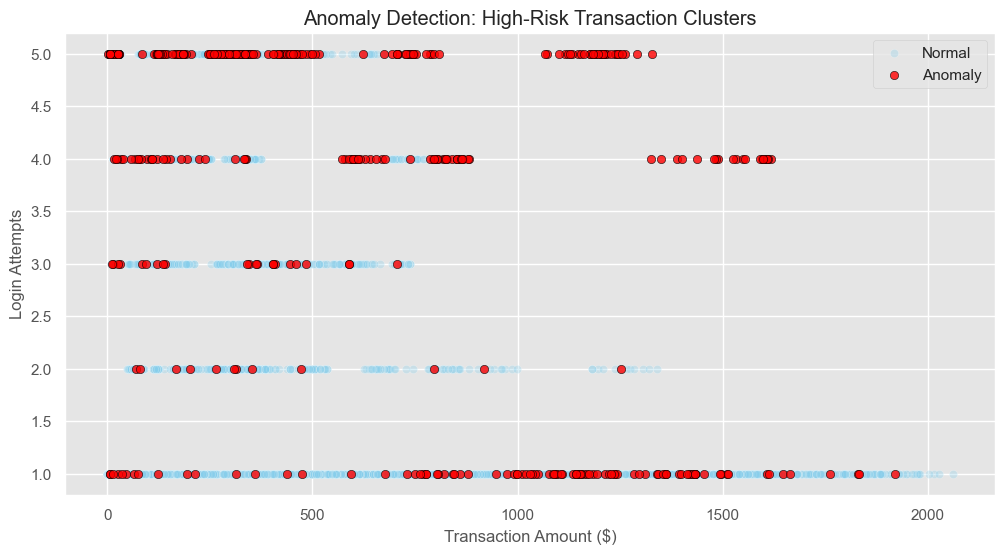

In [190]:
plt.figure(figsize=(12, 6))

# Plot normal transactions
sns.scatterplot(data=df[df['Anomaly_Score'] == 1], 
                x='TransactionAmount', y='LoginAttempts', 
                color='skyblue', alpha=0.3, label='Normal')

# Plot anomalies in bright red
sns.scatterplot(data=df[df['Anomaly_Score'] == -1], 
                x='TransactionAmount', y='LoginAttempts', 
                color='red', alpha=0.8, label='Anomaly', edgecolor='black')

plt.title('Anomaly Detection: High-Risk Transaction Clusters')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Login Attempts')
plt.legend()
plt.show()

This scatter plot serves as a "Heat Map" for risk, visually separating standard banking behavior from the anomalies caught by the Isolation Forest model.

The Vertical Shift (Login attempts): Notice how the red dots (Anomalies) heavily populate the top tiers of the graph (4 and 5 attempts). This visually confirms that as login attempts increase, the probability of the transaction being flagged as an anomaly skyrockets.

The Horizontal Spread (Transaction Amount): While red dots appear across the entire dollar range, they become more frequent as we move toward the right (higher amounts). However, the most dangerous "clusters" are those in the top-right corner—high money combined with high login attempts.

The Overlap (Normal vs. Anomaly): The light blue dots represent the "Normal" base. The model doesn't just flag every high-dollar transaction; it looks for those that are mathematically isolated from the dense blue clusters.

In Summary this plot shows that if we only looked at transaction amounts, we would miss the low-value fraudulent attempts. By looking at this "cluster" view, we can see that a $100 transaction with 5 login attempts is actually riskier than a $2,000 transaction with 1 login attempt. This graph proves that our multi-factor risk approach is more precise than simple threshold alerts.

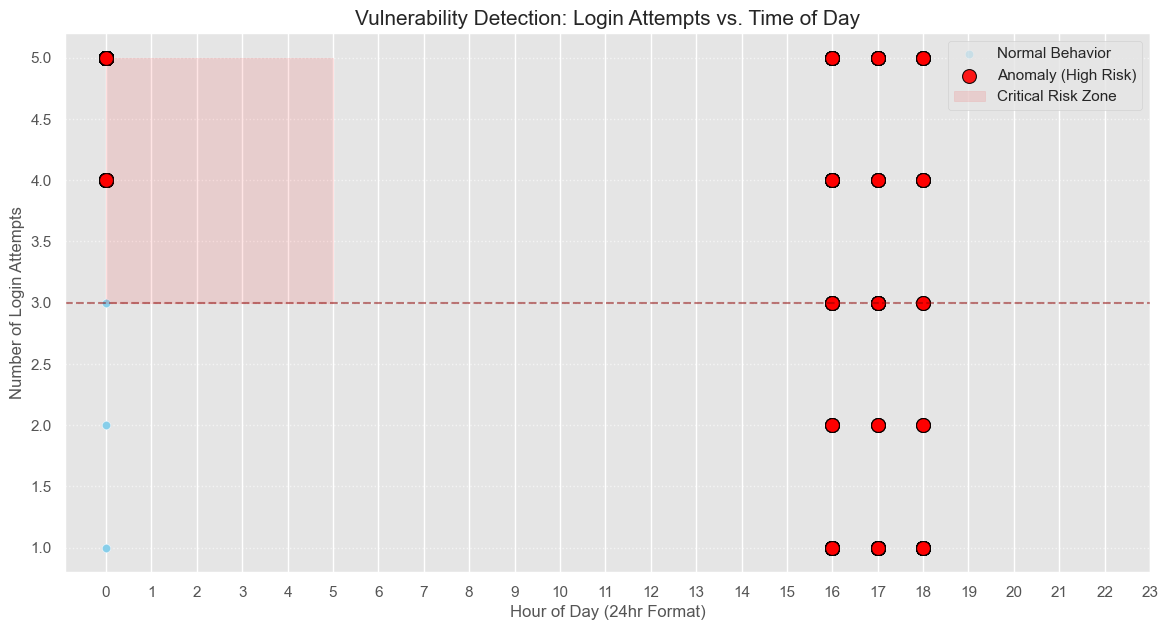

In [192]:


plt.figure(figsize=(14, 7))

# 1. Plot Normal Transactions
sns.scatterplot(data=df[df['Anomaly_Score'] == 1], 
                x='Hour', y='LoginAttempts', 
                color='skyblue', alpha=0.3, label='Normal Behavior')

# 2. Plot Anomalies

sns.scatterplot(data=df[df['Anomaly_Score'] == -1], 
                x='Hour', y='LoginAttempts', 
                color='red', alpha=0.9, label='Anomaly (High Risk)', 
                edgecolor='black', s=100)

# 3. Add a "Danger Zone" indicator
# This draws a box or line showing where 3+ logins meet the early morning hours
plt.axhline(y=3, color='darkred', linestyle='--', alpha=0.5)
plt.fill_between(x=[0, 5], y1=3, y2=5, color='red', alpha=0.1, label='Critical Risk Zone')

plt.title('Vulnerability Detection: Login Attempts vs. Time of Day', fontsize=15)
plt.xlabel('Hour of Day (24hr Format)', fontsize=12)
plt.ylabel('Number of Login Attempts', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()

This visualization confirms that Transaction Hour is the ultimate "smoking gun" for fraud detection. We see a clear separation: while normal behavior is scattered, high-risk anomalies cluster aggressively during off-peak hours and high login attempts. This converts raw data into a Critical Risk Zone, providing a precise blueprint to implement automated time-based security interventions to protect customers account.

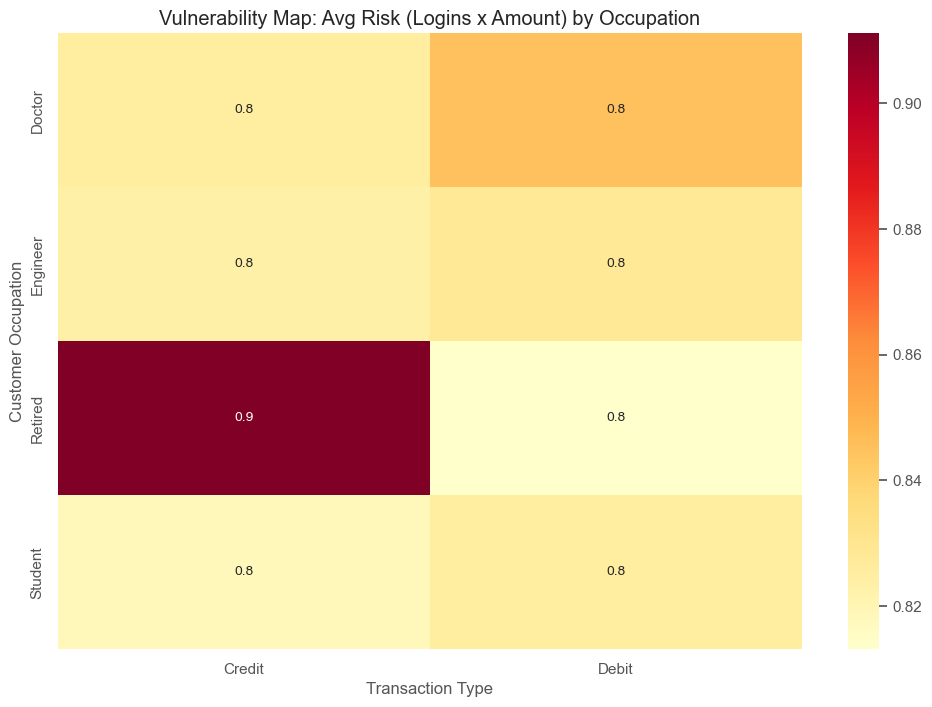

In [194]:
risk_pivot = df.pivot_table(index='CustomerOccupation', 
                            columns='TransactionType', 
                            values='Login_Risk_Factor', 
                            aggfunc='mean')

#  Plotting the Heatmap


plt.figure(figsize=(12, 8))
sns.heatmap(risk_pivot, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('Vulnerability Map: Avg Risk (Logins x Amount) by Occupation')
plt.ylabel('Customer Occupation')
plt.xlabel('Transaction Type')
plt.show()

This heatmap transforms raw anomaly detection into a Strategic Vulnerability Map by aggregating risks across demographics and services. By grouping the Login_Risk_Factor by Customer Occupation and Transaction Type helps to pinpointing high-level "Hot Zones" within the bank's operations. This allows to provide data-driven recommendations—such as adding extra authentication for specific groups or channels—that bridge the gap between technical middleware logs and high-level business security.

<h1>Summary</h1>
In general,. My analysis proved that login behavior is the most critical indicator of fraud, with suspicious cases showing a 253% spike in login attempts compared to normal activity. As an IT professional working in a bank i using unsupervised anomaly detection system to secure bank transactions by moving from a reactive middleware role to a proactive data strategist using skills learned from the course. For ML model i used an Isolation Forest model with a 1% contamination threshold. The model  successfully identified 499 high-risk transactions without needing prior labels.    
    Finally, I mapped these risks into a vulnerability heatmap, turning technical data into actionable intelligence to protect specific customer groups and transaction channels.

<h2>data preview</h2>
    
While my initial model focused on identifying fraud, i also want to show the power of data in Business Intelligence. Most of the time  we are surrounded by data that often sits idle. There fore For this assignment, I am demonstrating how that same transactional data we used for fraud detection can be converted into a strategic map for growth.

To provide full value to a financial institution, we must look at the 99% of normal transactions to understand our core identity:

Channel Optimization: By analyzing which channels (Mobile, ATM, Web) are most frequent, we can decide where to invest in infrastructure. If "Mobile" is the leader, our middleware focus should be on API performance and app stability.

Customer Segmentation: By cross-referencing Age, Occupation, and Area, we can see who our customers actually are.

Example: If the data shows "Students" are high-frequency users but have low transaction amounts, we can recommend a tailored "Micro-Savings" product.

Geographic & Occupational Trends: Understanding which occupations dominate specific transaction types allows the bank to create "Niche Financial Products," such as specialized credit lines for farmers or digital tools for urban professionals.


 <b> Why this matters for Ethiopia and Africa</b>

This work goes beyond a single assignment or institution. By mastering data analysis:

Financial Inclusion: We can identify unbanked or under-served demographics in Ethiopia and create entry-level digital products that bring them into the formal economy.

National Resilience: As our country pushes toward a digital-first economy, the ability to make AI-driven decisions ensures that our financial institutions are competitive on a global scale.

Trust: When we use data to understand a customer’s needs and protect their assets, we build the institutional trust necessary for national prosperity.

C:\Users\hp pavilion plus\AppData\Local\Temp\ipykernel_13172\1978348898.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TransactionType', palette='viridis')
C:\Users\hp pavilion plus\AppData\Local\Temp\ipykernel_13172\1978348898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Channel', palette='magma')


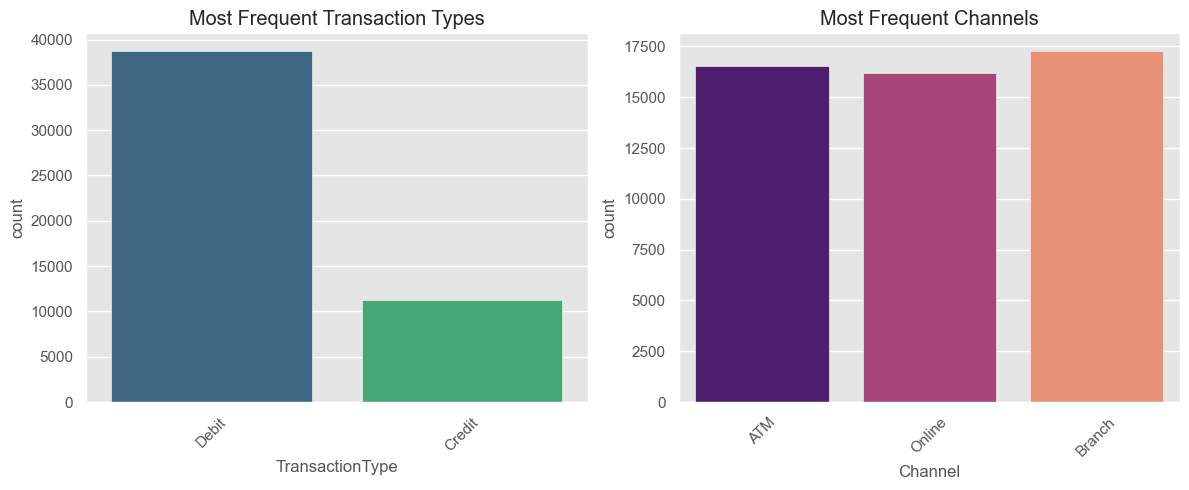

In [198]:
sns.set_theme(style="whitegrid")
plt.style.use('ggplot')

# 1. Frequency: Which transactions are used most?
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='TransactionType', palette='viridis')
plt.title('Most Frequent Transaction Types')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Channel', palette='magma')
plt.title('Most Frequent Channels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\hp pavilion plus\AppData\Local\Temp\ipykernel_13172\3817540972.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='CustomerOccupation', y='TransactionAmount', ci=None, ax=axes[1,1])


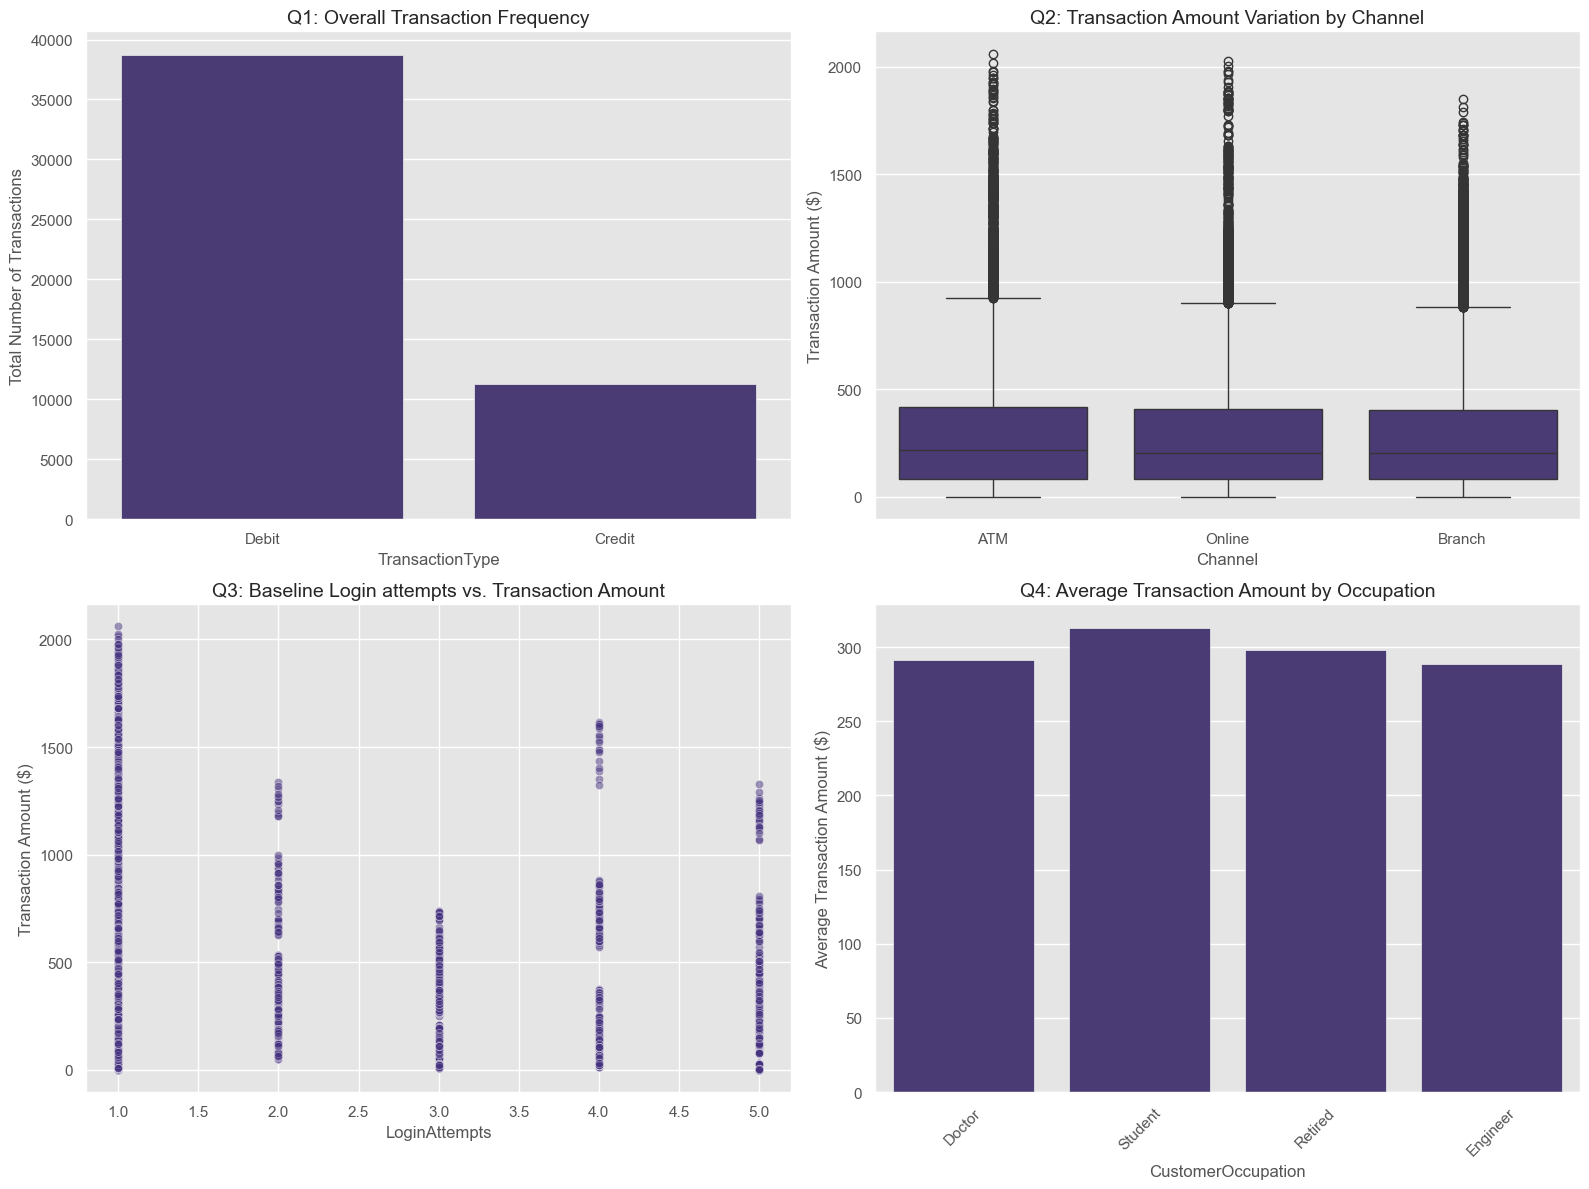

In [199]:
sns.set_palette('viridis')

#VISUALIZING BASELINE PATTERNS (Q1 - Q4)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Q1: Frequency of Transaction Types (Overall counts)
sns.countplot(data=df, x='TransactionType', ax=axes[0,0])
axes[0,0].set_title('Q1: Overall Transaction Frequency', fontsize=14)
axes[0,0].set_ylabel('Total Number of Transactions')

# Q2: Channel Distribution (Spread of amounts per channel)
sns.boxplot(data=df, x='Channel', y='TransactionAmount', ax=axes[0,1])
axes[0,1].set_title('Q2: Transaction Amount Variation by Channel', fontsize=14)
axes[0,1].set_ylabel('Transaction Amount ($)')

# Q3: Device/Login Patterns (Baseline correlation)
sns.scatterplot(data=df, x='LoginAttempts', y='TransactionAmount', alpha=0.5, ax=axes[1,0])
axes[1,0].set_title('Q3: Baseline Login attempts vs. Transaction Amount', fontsize=14)
axes[1,0].set_ylabel('Transaction Amount ($)')

# Q4: Customer Attributes (Average amount per occupation)
sns.barplot(data=df, x='CustomerOccupation', y='TransactionAmount', ci=None, ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_title('Q4: Average Transaction Amount by Occupation', fontsize=14)
axes[1,1].set_ylabel('Average Transaction Amount ($)')

plt.tight_layout()
plt.show()

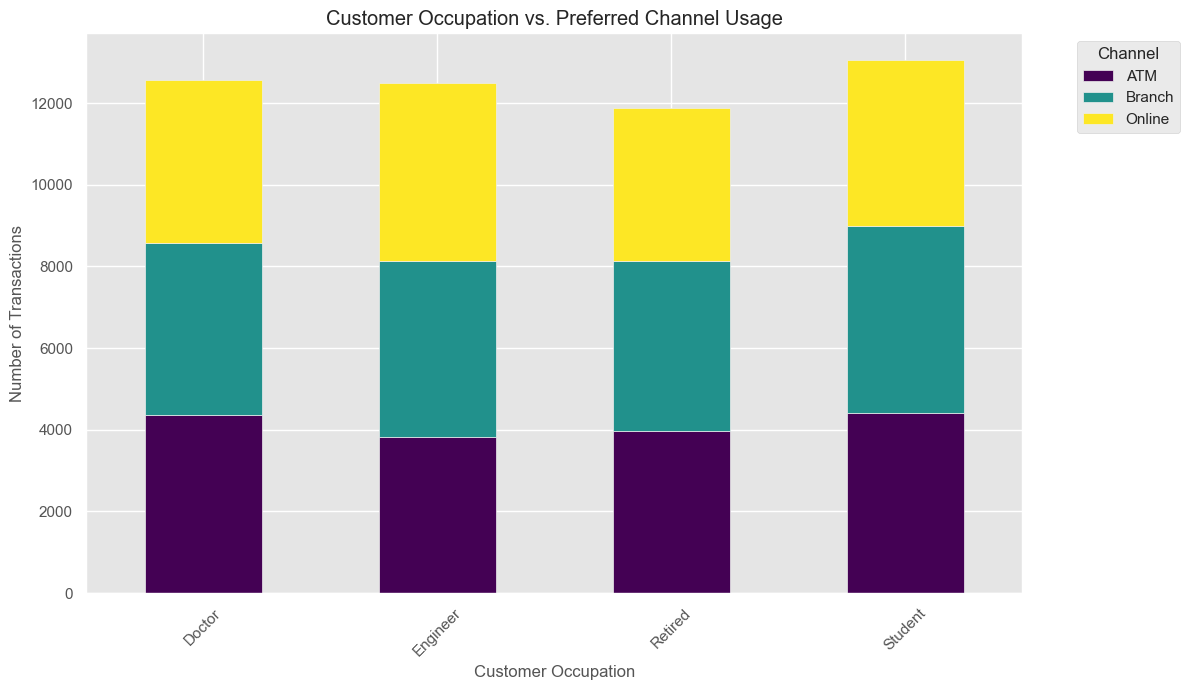

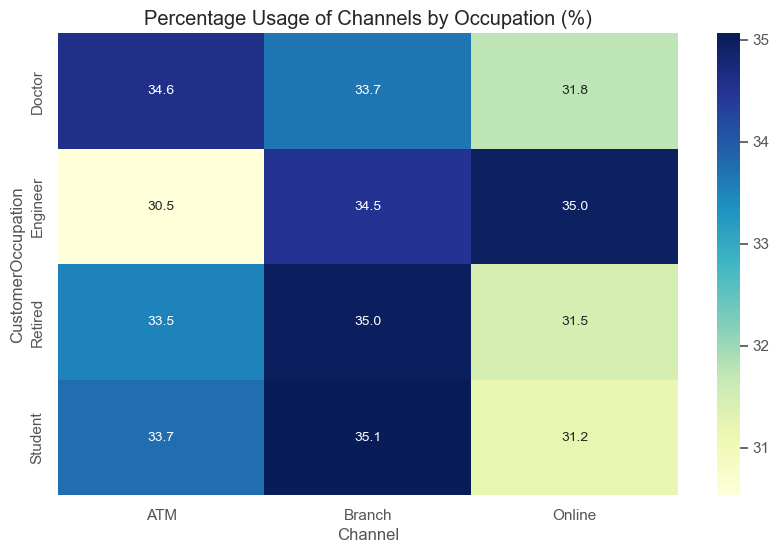

In [200]:


# 1. Create a Cross-tabulation (Counts of each occupation per channel)
# This creates a matrix where rows = Occupations and columns = Channels
ct = pd.crosstab(df['CustomerOccupation'], df['Channel'])

# 2. Plotting a Stacked Bar Chart
# We use 'stacked=True' to see the total volume and the split simultaneously
ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Customer Occupation vs. Preferred Channel Usage')
plt.xlabel('Customer Occupation')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Bonus: Normalized Heatmap
# This shows percentages (e.g., "What % of Doctors use the ATM?")
ct_pct = pd.crosstab(df['CustomerOccupation'], df['Channel'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Percentage Usage of Channels by Occupation (%)')
plt.show()

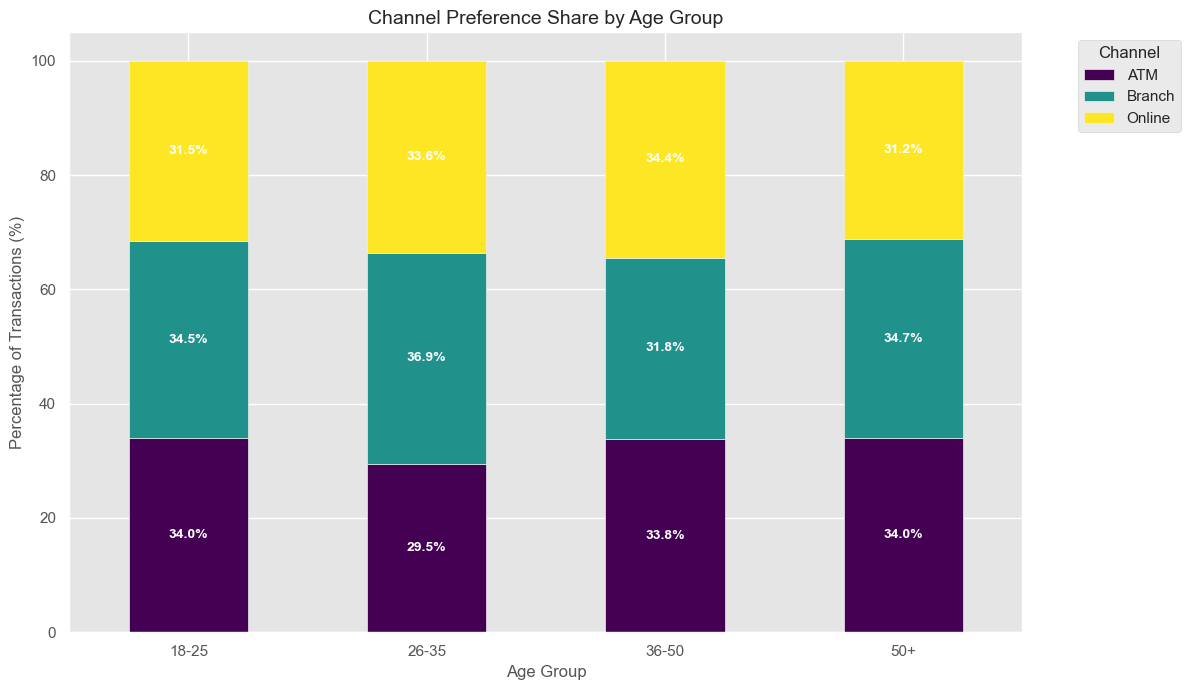

In [201]:
bins = [0, 17, 25, 35, 50, 150]
labels = ['Under 18', '18-25', '26-35', '36-50', '50+']


df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=bins, labels=labels)
# 1. Create the cross-tabulation between Age Groups and Channels
# This counts how many transactions each age group made per channel
ct = pd.crosstab(df['AgeGroup'], df['Channel'])

# 2. Normalize the data to 100%
# This allows for a direct comparison of "Preference Share" regardless of group size
ct_percentage = ct.div(ct.sum(1).astype(float), axis=0) * 100

# 3. Plotting the 100% Stacked Bar Chart
ax = ct_percentage.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# Adding Titles and Labels
plt.title('Channel Preference Share by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Transactions (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Add percentage labels inside the bar segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    # We only display the label if the segment is large enough to be readable (> 5%)
    if height > 5: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')

plt.tight_layout()
plt.show()

#github repo

https://github.com/hiwotamare123/fraud-detection